# GeoBench Substation

The substation dataset is a multi-spectral S2 dataset for instance segmentation power substation globally. Originally multi-temporal, as part of GEO-Bench-2 we created cloud free composites and subsampled to deduce computational complexity.

Reference

* Jindgar, K., & Lindsay, G. W. (2024). Improving satellite imagery segmentation using multiple Sentinel-2 revisits. arXiv preprint arXiv:2409.17363.

In [23]:
import os
from pathlib import Path

import torch

from geobench_v2.datamodules import GeoBenchSubstationDataModule
from geobench_v2.datasets import GeoBenchSubstation

from geobench_v2.datasets.visualization_util import (
    compare_normalization_methods,
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
PROJECT_ROOT = Path("../../")

In [19]:
band_order = GeoBenchSubstation.band_default_order

datamodule = GeoBenchSubstationDataModule(
    img_size=256,
    batch_size=4,
    num_workers=4,
    root=PROJECT_ROOT,
    band_order=band_order,
    download=True # we do custom normalization in the tutorial
)
datamodule.setup("fit")

Initializing normalizer from class: ZScoreNormalizer
Initializing normalizer from class: ZScoreNormalizer


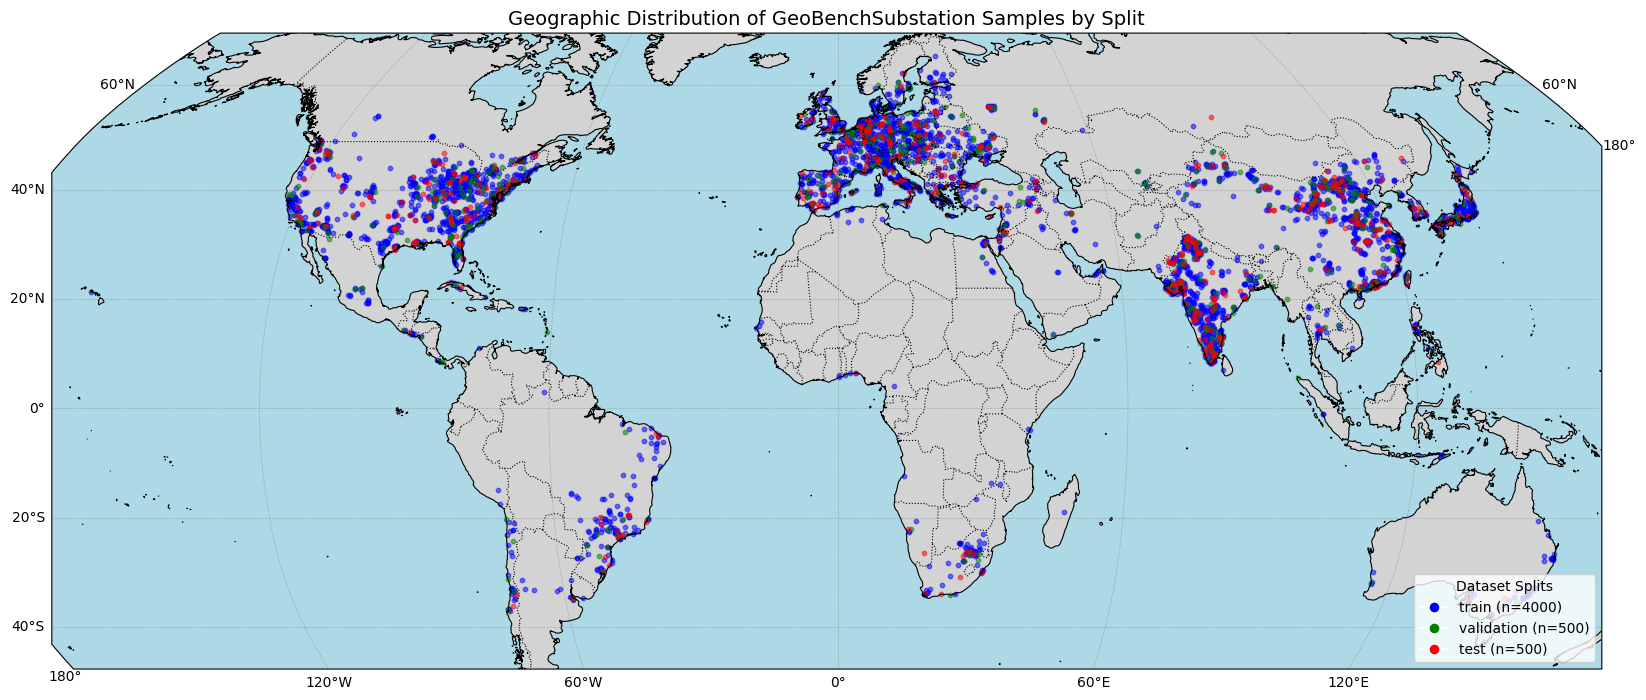

In [20]:
sample_dist_fig = datamodule.visualize_geospatial_distribution()

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>]

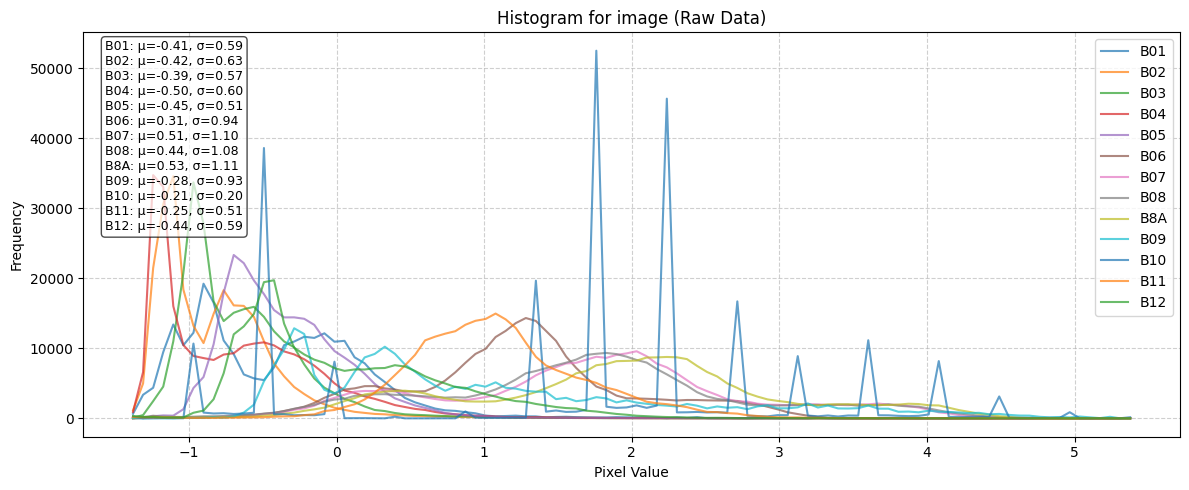

In [21]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

## Visualize Batch Data

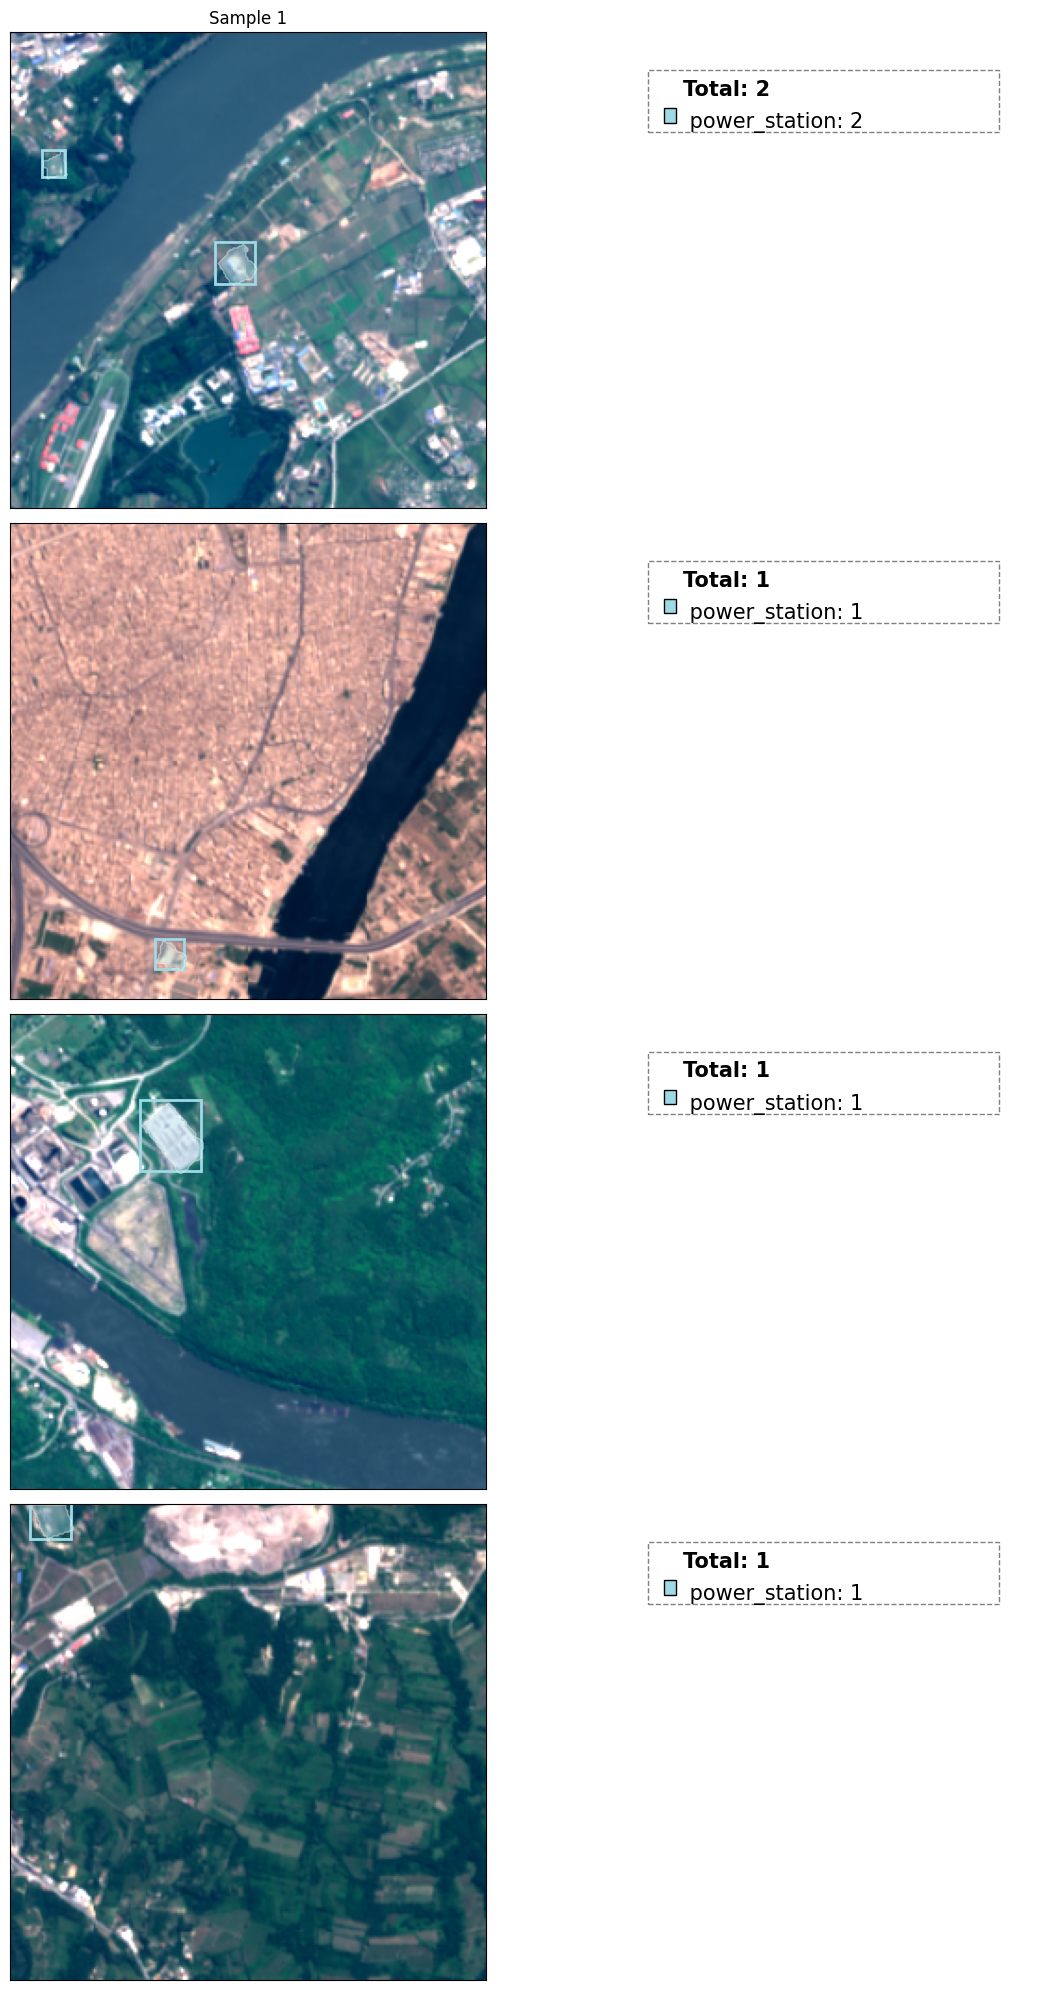

In [22]:
fig, batch = datamodule.visualize_batch()